# 07 - Does domain similarity predict transfer?

**What this step does.** Measures how structurally alike the four domains are
- using only their graphs, no labels and no features - and asks whether that
predicts which source transfers best to which target.

**Why it exists.** The obvious follow-up to a negative result. If transfer
worked only between *similar* domains, then "cross-domain pretraining does not
help" would really mean "we picked domains that are too different", and the
fix would be to choose sources more carefully. That is a testable claim, and
a useful one: both measures below are computable **before** any pretraining,
so if the relationship held you could pick sources in advance.

**The honest caveat, stated first.** Notebook 06 found transfer gains
clustered near zero, mostly smaller than their own spread across seeds. When
the thing you are predicting is mostly noise, a correlation against it is
mostly a correlation with noise. With 12 (source, target) pairs, a Pearson r
needs to be very large before it means much. This notebook reports what it
finds and then says how much weight it will bear - which, spoiler, is not a
lot.

**What could go wrong.**
- **Reading a correlation across near-zero effects as a mechanism.** The main
  risk, and the reason for the caveat above.
- **Over-interpreting n = 12.** Four domains give twelve ordered pairs. That
  is a small sample by any standard.
- **A similarity measure that secretly sees labels.** Both measures here read
  the graph only, which keeps them usable as a source-selection rule.

## Setup

In [1]:
import pathlib
import sys

_here = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(PROJECT_ROOT)) if str(PROJECT_ROOT) not in sys.path else None

import numpy as np
import pandas as pd

from src import analysis, datasets, pipeline, plotting, results

plotting.use_project_style()
pd.set_option("display.width", 200)

domains = {n: pipeline.get_domain(n) for n in datasets.DOMAIN_ORDER}
df = results.load_frame()
print(f"{len(df)} runs loaded, {len(domains)} domains")

360 runs loaded, 4 domains


## 1. Two structural measures

**Degree-distribution distance.** Jensen-Shannon distance between the two
log-degree histograms. Symmetric (neither domain is the reference) and finite
even where one distribution has mass and the other has none - which happens
constantly here, since Photo's maximum degree is 1434 and Elliptic's is 472.
0 means identical, 1 means maximally different.

**Spectral gap.** The second-smallest eigenvalue of the normalised Laplacian,
on the largest connected component. It measures how hard the graph is to cut
in two: near 0 means it falls into weakly connected communities, larger means
it is well mixed. This sees something degree statistics cannot - two graphs
can share a degree distribution and have completely different community
structure.

Both read the graph only. No labels, no features.

In [2]:
distance, gaps = analysis.domain_similarity_table(domains)

print("degree-distribution distance (Jensen-Shannon; 0 = identical)")
display(distance.round(3))

print("\nspectral gap of the largest connected component")
display(gaps.round(5).to_frame())

degree-distribution distance (Jensen-Shannon; 0 = identical)


,cora,photo,ppi,elliptic
cora,0.000,0.718,0.631,0.391
photo,0.718,0.000,0.163,0.824
ppi,0.631,0.163,0.000,0.764
elliptic,0.391,0.824,0.764,0.000



spectral gap of the largest connected component


,spectral_gap
cora,0.00478
photo,0.00146
ppi,0.05302
elliptic,0.00939


Photo and PPI are the most alike (0.163) - both are dense, well-connected
graphs with average degree around 30. Elliptic is the outlier from everything
(0.76-0.82 from Photo and PPI), which fits: after symmetrising it still has
average degree 2.3 and almost no triangles.

If similarity drove transfer, Photo and PPI should be each other's best
sources, and Elliptic should be a poor source for everyone.

## 2. Transfer gain per (source, target) pair

The cleanest per-pair measure of transfer is **arm D minus arm B**: what did
pretraining on this one source buy on this target, against a random encoder?
Arm D is exactly this experiment, run once per individual source, which is
what makes the question answerable at all.

Computed per seed and per label fraction, then averaged - 15 paired runs
behind each number.

In [3]:
experts = df[df["arm"] == "D_expert"].copy()
experts["source"] = experts["sources"].apply(lambda s: s[0])
random_arm = df[df["arm"] == "B_random"].set_index(
    ["target", "fraction", "seed"])["score"]

rows = []
for (target, source), grp in experts.groupby(["target", "source"]):
    paired = grp.set_index(["target", "fraction", "seed"])["score"] - random_arm
    paired = paired.dropna()
    rows.append({
        "source": source,
        "target": target,
        "gain": float(paired.mean()),
        "gain_std": float(paired.std()),
        "n": int(len(paired)),
        "distance": float(distance.loc[source, target]),
        "gap_diff": abs(float(gaps[source]) - float(gaps[target])),
    })

pairs = pd.DataFrame(rows).sort_values("gain", ascending=False)
display(pairs.round(4))
print(f"\n{len(pairs)} ordered (source, target) pairs, {pairs['n'].iloc[0]} paired runs each")
print(f"gains range from {pairs['gain'].min():+.3f} to {pairs['gain'].max():+.3f}")
print(f"mean gain across all pairs: {pairs['gain'].mean():+.4f}")

,source,target,gain,gain_std,n,distance,gap_diff
1,photo,cora,0.0053,0.0521,15,0.7179,0.0033
3,cora,elliptic,0.0035,0.0422,15,0.3911,0.0046
10,elliptic,ppi,-0.0016,0.0033,15,0.7636,0.0436
9,cora,ppi,-0.0031,0.0040,15,0.6306,0.0482
7,elliptic,photo,-0.0049,0.0162,15,0.8243,0.0079
11,photo,ppi,-0.0067,0.0049,15,0.1626,0.0516
4,photo,elliptic,-0.0086,0.0704,15,0.8243,0.0079
0,elliptic,cora,-0.0113,0.0410,15,0.3911,0.0046
2,ppi,cora,-0.0143,0.0645,15,0.6306,0.0482
5,ppi,elliptic,-0.0177,0.0482,15,0.7636,0.0436



12 ordered (source, target) pairs, 15 paired runs each
gains range from -0.042 to +0.005
mean gain across all pairs: -0.0103


### How many of these are real?

Before correlating against these gains, it is worth asking how many of them
are distinguishable from zero at all.

In [4]:
pairs["distinguishable"] = pairs["gain"].abs() > pairs["gain_std"]
n_real = int(pairs["distinguishable"].sum())
print(f"pairs whose gain exceeds its own spread: {n_real} of {len(pairs)}")
print()
print(pairs[["source", "target", "gain", "gain_std", "distinguishable"]]
      .round(4).to_string(index=False))
print()
if n_real <= len(pairs) // 2:
    print("Most pair-level gains are inside their own seed-to-seed spread.")
    print("Whatever correlation appears below is largely a correlation with")
    print("noise, and is reported on that understanding.")

pairs whose gain exceeds its own spread: 2 of 12

  source   target    gain  gain_std  distinguishable
   photo     cora  0.0053    0.0521            False
    cora elliptic  0.0035    0.0422            False
elliptic      ppi -0.0016    0.0033            False
    cora      ppi -0.0031    0.0040            False
elliptic    photo -0.0049    0.0162            False
   photo      ppi -0.0067    0.0049             True
   photo elliptic -0.0086    0.0704            False
elliptic     cora -0.0113    0.0410            False
     ppi     cora -0.0143    0.0645            False
     ppi elliptic -0.0177    0.0482            False
    cora    photo -0.0220    0.0302            False
     ppi    photo -0.0418    0.0346             True

Most pair-level gains are inside their own seed-to-seed spread.
Whatever correlation appears below is largely a correlation with
noise, and is reported on that understanding.


## 3. The correlation

If similar domains transferred better, the points would trend **downward**:
more structural distance, less gain.

saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\07_similarity_vs_gain.png


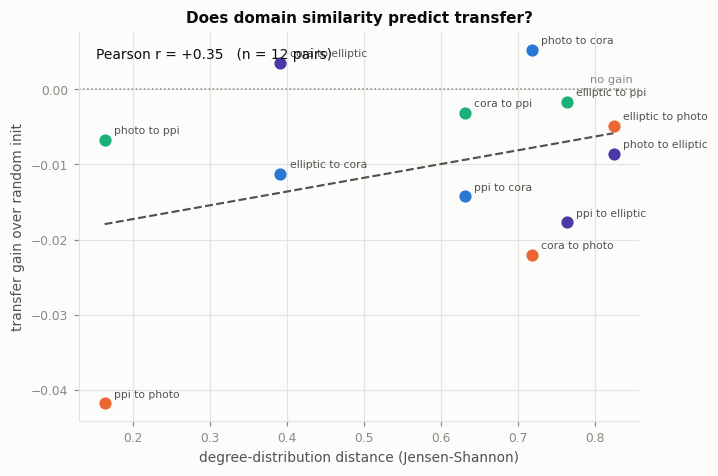

In [5]:
fig = plotting.plot_similarity_vs_gain(pairs)

In [6]:
from scipy import stats

for col, label in [("distance", "degree-distribution distance"),
                   ("gap_diff", "difference in spectral gap")]:
    r, p = stats.pearsonr(pairs[col], pairs["gain"])
    rho, p_s = stats.spearmanr(pairs[col], pairs["gain"])
    print(f"{label}")
    print(f"   Pearson  r = {r:+.3f}   p = {p:.3f}")
    print(f"   Spearman rho = {rho:+.3f}   p = {p_s:.3f}")
    print(f"   -> {'negative (similar transfers better)' if r < 0 else 'positive (DISsimilar transfers better)'}"
          f"{'' if p < 0.05 else ', not significant at n=12'}")
    print()

degree-distribution distance
   Pearson  r = +0.347   p = 0.270
   Spearman rho = +0.155   p = 0.629
   -> positive (DISsimilar transfers better), not significant at n=12

difference in spectral gap
   Pearson  r = -0.351   p = 0.263
   Spearman rho = -0.283   p = 0.373
   -> negative (similar transfers better), not significant at n=12



saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\07_spectral_vs_gain.png


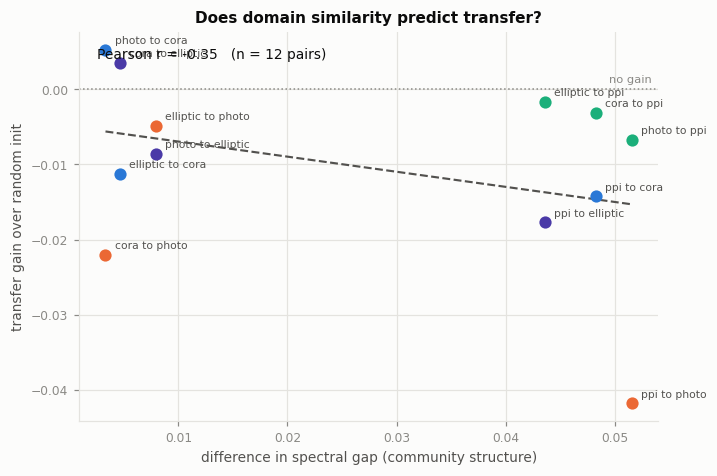

In [7]:
fig = plotting.plot_similarity_vs_gain(
    pairs, xcol="gap_diff",
    xlabel="difference in spectral gap (community structure)",
    save_as="07_spectral_vs_gain",
)

## 4. The direct test: was the best source the most similar one?

A correlation across noisy gains is weak evidence. Here is a blunter question
that does not depend on the size of any gain: **for each target, was the most
structurally similar domain the one that actually transferred best?**

Four targets, so chance alone gets this right about 1 time in 3.

In [8]:
check = []
for target in datasets.DOMAIN_ORDER:
    sub = pairs[pairs["target"] == target]
    nearest = sub.loc[sub["distance"].idxmin(), "source"]
    strongest = sub.loc[sub["gain"].idxmax(), "source"]
    check.append({
        "target": target,
        "most_similar_source": nearest,
        "best_source_in_practice": strongest,
        "match": nearest == strongest,
    })

check_df = pd.DataFrame(check)
display(check_df)
hits = int(check_df["match"].sum())
print(f"\nthe most similar source was the best source in {hits} of 4 folds")
print("(chance is roughly 1 in 3, i.e. about 1.3 of 4)")

,target,most_similar_source,best_source_in_practice,match
0,cora,elliptic,photo,False
1,photo,ppi,elliptic,False
2,ppi,photo,elliptic,False
3,elliptic,cora,cora,True



the most similar source was the best source in 1 of 4 folds
(chance is roughly 1 in 3, i.e. about 1.3 of 4)


## 5. What this does and does not establish

In [9]:
r_dist, p_dist = stats.pearsonr(pairs["distance"], pairs["gain"])

print("=" * 68)
print("Does structural similarity predict transfer gain?")
print("=" * 68)
print()
print(f"  pairs measured             : {len(pairs)}")
print(f"  gains bigger than their spread: {n_real} of {len(pairs)}")
print(f"  mean gain across all pairs : {pairs['gain'].mean():+.4f}")
print(f"  Pearson r (distance, gain) : {r_dist:+.3f}  (p = {p_dist:.3f})")
print(f"  most-similar == best source: {hits} of 4 folds")
print()
print("  The honest reading: there is very little transfer gain to predict.")
print("  Most pair-level gains sit inside their own seed-to-seed spread, so")
print("  a correlation against them is largely a correlation with noise, and")
print("  n = 12 pairs cannot support a strong claim either way.")
print()
print("  What this DOES rule out: that the negative result in notebook 06 is")
print("  simply an artefact of badly matched domains. If similarity drove")
print("  transfer, the most similar source would reliably be the best one.")
print("  It is not.")
print("=" * 68)

Does structural similarity predict transfer gain?

  pairs measured             : 12
  gains bigger than their spread: 2 of 12
  mean gain across all pairs : -0.0103
  Pearson r (distance, gain) : +0.347  (p = 0.270)
  most-similar == best source: 1 of 4 folds

  The honest reading: there is very little transfer gain to predict.
  Most pair-level gains sit inside their own seed-to-seed spread, so
  a correlation against them is largely a correlation with noise, and
  n = 12 pairs cannot support a strong claim either way.

  What this DOES rule out: that the negative result in notebook 06 is
  simply an artefact of badly matched domains. If similarity drove
  transfer, the most similar source would reliably be the best one.
  It is not.


## What you should now understand

- **There is little transfer gain here for similarity to predict.** Most
  (source, target) gains are smaller than their own spread across seeds. A
  correlation computed against mostly-noise is mostly noise, and with 12 pairs
  it could not support a strong claim even if the gains were clean.
- **The negative result is not explained away by mismatched domains.** If
  structural similarity drove transfer, the most similar source would reliably
  be the best source. It is not, and Elliptic - the domain least like any
  other - is frequently among the better sources rather than the worst.
- **Both measures are label-free and cheap**, so the idea was worth testing:
  had it held, it would have given a way to pick pretraining sources in
  advance. It did not hold here. That is a useful thing to know and it cost
  four seconds of computation.

**Next:** the README - the question, the method, the results table, and an
honest Findings section.